# Notebook 1: EDA and Feature Engineering (LLM-Ready Revision)

This notebook performs:

- reproducibility logging
- raw dataset inspection
- preprocessing and filtering
- expanded experience-level mapping
- exploratory data analysis (EDA)
- non-LLM feature engineering for experience and responsibility signals
- creation of `semantic_text` for Notebook 2
- export of cleaned and enriched datasets

**Notes:**
- Skill extraction is **not** done here via a predefined taxonomy.
- Skills will be surfaced later by the **LLM at the community level in Notebook 3**.


In [13]:
import os
import sys
import json
import shutil
import hashlib
import platform
import datetime
import subprocess
import warnings
import re
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 200)

In [14]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

seed_info = {"random_seed": RANDOM_SEED}

with open("seed_log.json", "w", encoding="utf-8") as f:
    json.dump(seed_info, f, indent=2)

print("Saved: seed_log.json")

Saved: seed_log.json


In [15]:
env_log = {
    "timestamp_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(),
    "python_version": sys.version,
    "platform": platform.platform(),
    "processor": platform.processor(),
    "working_directory": os.getcwd(),
    "packages": {}
}

if shutil.which("nvidia-smi"):
    try:
        env_log["gpu"] = subprocess.check_output(
            [
                "nvidia-smi",
                "--query-gpu=name,memory.total,driver_version",
                "--format=csv,noheader"
            ],
            text=True
        ).strip()
    except Exception as e:
        env_log["gpu"] = f"ERROR: {e}"

if shutil.which("nvcc"):
    try:
        env_log["cuda"] = subprocess.check_output(
            ["nvcc", "--version"],
            text=True
        ).strip().split("\n")[-1]
    except Exception as e:
        env_log["cuda"] = f"ERROR: {e}"

try:
    import psutil
    env_log["ram_gb"] = round(psutil.virtual_memory().total / 1024**3, 2)
except Exception:
    env_log["ram_gb"] = "psutil not available"

package_names = ["os", "sys", "json", "shutil", "hashlib", "platform", "datetime", "subprocess", "warnings", "re", "Counter", "pandas", "numpy", "matplotlib", "psutil"]

for pkg in package_names:
    try:
        module = __import__(pkg)
        env_log["packages"][pkg] = getattr(module, "__version__", "installed")
    except ImportError:
        env_log["packages"][pkg] = "NOT INSTALLED"

ENV_FILE = "environment_log.json"
with open(ENV_FILE, "w", encoding="utf-8") as f:
    json.dump(env_log, f, indent=2, ensure_ascii=False)

print(json.dumps(env_log, indent=2))
print(f"\nSaved: {ENV_FILE}")

{
  "timestamp_utc": "2026-03-29T13:13:34.764968+00:00",
  "python_version": "3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]",
  "platform": "Linux-6.6.113+-x86_64-with-glibc2.35",
  "processor": "x86_64",
  "working_directory": "/content",
  "packages": {
    "os": "installed",
    "sys": "installed",
    "json": "2.0.9",
    "shutil": "installed",
    "hashlib": "installed",
    "platform": "1.0.8",
    "datetime": "installed",
    "subprocess": "installed",
    "warnings": "installed",
    "re": "2.2.1",
    "Counter": "NOT INSTALLED",
    "pandas": "2.2.2",
    "numpy": "2.0.2",
    "matplotlib": "3.10.0",
    "psutil": "5.9.5"
  },
  "gpu": "Tesla T4, 15360 MiB, 580.82.07",
  "cuda": "Build cuda_12.8.r12.8/compiler.35583870_0",
  "ram_gb": 12.67
}

Saved: environment_log.json


In [16]:
# ============================================================
# INPUT FILE INTEGRITY CHECK (SHA-256)
# ============================================================
import hashlib
EXPECTED_SHA256 = "de33f27c8d1b226014e0cede003404e9b0acb66db718671fda9b3e3538eca6ea"
sha256 = hashlib.sha256()
with open("postings.csv", "rb") as f:
    for block in iter(lambda: f.read(8192), b""):
        sha256.update(block)
actual = sha256.hexdigest()
if actual == EXPECTED_SHA256:
    print(f"   SHA-256 MATCH — input file is intact")
    print(f"   {actual}")
else:
    print(f"   SHA-256 MISMATCH — input file may be corrupted or wrong!")
    print(f"   Expected: {EXPECTED_SHA256}")
    print(f"   Got:      {actual}")
    raise ValueError("Input file SHA-256 does not match. Aborting.")

   SHA-256 MATCH — input file is intact
   de33f27c8d1b226014e0cede003404e9b0acb66db718671fda9b3e3538eca6ea


In [17]:
DATA_FILE = "postings.csv"
df = pd.read_csv(DATA_FILE)

print("Raw shape:", df.shape)
df.head()

Raw shape: (123849, 31)


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,min_salary,formatted_work_type,applies,original_listed_time,remote_allowed,job_posting_url,application_url,application_type,expiry,closed_time,formatted_experience_level,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,"Job descriptionA leading real estate firm in New Jersey is seeking an administrative Marketing Coordinator with some experience in graphic design. You will be working closely with our fun, kind, a...",20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,17.0,Full-time,2.0,1.713398e+12,NaN,https://www.linkedin.com/jobs/view/921716/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,1.715990e+12,NaN,NaN,"Requirements: \n\nWe are seeking a College or Graduate Student (can also be completed with school) with a focus in Planning, Architecture, Real Estate Development or Management or General Business...",1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committed to serving clients with best practices to help them with change, improvements and better quality of life. We believe in providing a secure, support...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,30.0,Full-time,NaN,1.712858e+12,NaN,https://www.linkedin.com/jobs/view/1829192/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,1.715450e+12,NaN,NaN,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,"The National Exemplar is accepting applications for an Assistant Restaurant Manager.\nWe offer highly competitive wages, healthcare, paid time off, complimentary dining privileges and bonus opport...",65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,45000.0,Full-time,NaN,1.713278e+12,NaN,https://www.linkedin.com/jobs/view/10998357/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,1.715870e+12,NaN,NaN,We are currently accepting resumes for FOH - Asisstant Restaurant Management with a strong focus on delivering high quality customer service. Prefer 1 to 3 years FOH management experience. Candida...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associate Attorney,"Senior Associate Attorney - Elder Law / Trusts and Estates Our legal team is committed to providing each client with quality counsel, innovative solutions, and personalized service. Founded in 20...",175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,140000.0,Full-time,NaN,1.712896e+12,NaN,https://www.linkedin.com/jobs/view/23221523/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,1.715488e+12,NaN,NaN,"This position requires a baseline understanding of online marketing including Search Engine Marketing, Search Engine Optimization, and campaign analytics. The ideal candidate must be an analytical...",1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience in commerical and industrial equipment. Minimum 5 yrs. on the job with mechanical license. Winger is a full line union mechanical business with Piping...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,60000.0,Full-time,NaN,1.713452e+12,NaN,https://www.linkedin.com/jobs/view/35982263/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,1.716044e+12,NaN,NaN,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


In [18]:
def sha256_of_file(filepath, chunk_size=8192):
    sha256 = hashlib.sha256()
    with open(filepath, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            sha256.update(chunk)
    return sha256.hexdigest()

dataset_hash_info = {
    "file_name": DATA_FILE,
    "sha256": sha256_of_file(DATA_FILE)
}

with open("dataset_hash.json", "w", encoding="utf-8") as f:
    json.dump(dataset_hash_info, f, indent=2)

print(json.dumps(dataset_hash_info, indent=2))
print("Saved: dataset_hash.json")

{
  "file_name": "postings.csv",
  "sha256": "de33f27c8d1b226014e0cede003404e9b0acb66db718671fda9b3e3538eca6ea"
}
Saved: dataset_hash.json


In [19]:
print("Columns:\n")
for col in df.columns:
    print(col)

Columns:

job_id
company_name
title
description
max_salary
pay_period
location
company_id
views
med_salary
min_salary
formatted_work_type
applies
original_listed_time
remote_allowed
job_posting_url
application_url
application_type
expiry
closed_time
formatted_experience_level
skills_desc
listed_time
posting_domain
sponsored
work_type
currency
compensation_type
normalized_salary
zip_code
fips


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  object 
 2   title                       123849 non-null  object 
 3   description                 123842 non-null  object 
 4   max_salary                  29793 non-null   float64
 5   pay_period                  36073 non-null   object 
 6   location                    123849 non-null  object 
 7   company_id                  122132 non-null  float64
 8   views                       122160 non-null  float64
 9   med_salary                  6280 non-null    float64
 10  min_salary                  29793 non-null   float64
 11  formatted_work_type         123849 non-null  object 
 12  applies                     23320 non-null   float64
 13  original_liste

In [21]:
missing_summary = (
    df.isna().sum()
      .sort_values(ascending=False)
      .to_frame("missing_count")
)

missing_summary["missing_percent"] = (
    missing_summary["missing_count"] / len(df) * 100
).round(2)

missing_summary.head(20)

,missing_count,missing_percent
closed_time,122776,99.13
skills_desc,121410,98.03
med_salary,117569,94.93
remote_allowed,108603,87.69
applies,100529,81.17
min_salary,94056,75.94
max_salary,94056,75.94
currency,87776,70.87
compensation_type,87776,70.87
pay_period,87776,70.87


In [22]:
print("Full duplicate rows:", df.duplicated().sum())

Full duplicate rows: 0


In [23]:
important_cols = [
    "job_id",
    "company_name",
    "title",
    "description",
    "formatted_experience_level",
    "formatted_work_type",
    "skills_desc",
    "normalized_salary",
    "currency",
    "location",
    "remote_allowed"
]

existing_important_cols = [c for c in important_cols if c in df.columns]
df[existing_important_cols].head(10)

,job_id,company_name,title,description,formatted_experience_level,formatted_work_type,skills_desc,normalized_salary,currency,location,remote_allowed
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,"Job descriptionA leading real estate firm in New Jersey is seeking an administrative Marketing Coordinator with some experience in graphic design. You will be working closely with our fun, kind, a...",NaN,Full-time,"Requirements: \n\nWe are seeking a College or Graduate Student (can also be completed with school) with a focus in Planning, Architecture, Real Estate Development or Management or General Business...",38480.0,USD,"Princeton, NJ",NaN
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committed to serving clients with best practices to help them with change, improvements and better quality of life. We believe in providing a secure, support...",NaN,Full-time,NaN,83200.0,USD,"Fort Collins, CO",NaN
2,10998357,The National Exemplar,Assitant Restaurant Manager,"The National Exemplar is accepting applications for an Assistant Restaurant Manager.\nWe offer highly competitive wages, healthcare, paid time off, complimentary dining privileges and bonus opport...",NaN,Full-time,We are currently accepting resumes for FOH - Asisstant Restaurant Management with a strong focus on delivering high quality customer service. Prefer 1 to 3 years FOH management experience. Candida...,55000.0,USD,"Cincinnati, OH",NaN
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associate Attorney,"Senior Associate Attorney - Elder Law / Trusts and Estates Our legal team is committed to providing each client with quality counsel, innovative solutions, and personalized service. Founded in 20...",NaN,Full-time,"This position requires a baseline understanding of online marketing including Search Engine Marketing, Search Engine Optimization, and campaign analytics. The ideal candidate must be an analytical...",157500.0,USD,"New Hyde Park, NY",NaN
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience in commerical and industrial equipment. Minimum 5 yrs. on the job with mechanical license. Winger is a full line union mechanical business with Piping...,NaN,Full-time,NaN,70000.0,USD,"Burlington, IA",NaN
5,91700727,Downtown Raleigh Alliance,Economic Development and Planning Intern,"Job summary:The Economic Development & Planning Intern will provide valuable support to the Economic Development & Planning team, with a specific focus on urban planning and transportation initiat...",NaN,Internship,NaN,35360.0,USD,"Raleigh, NC",NaN
6,103254301,Raw Cereal,Producer,"Company DescriptionRaw Cereal is a creative design agency specializing in live, interactive, corporate, and installation-based entertainment. Our mission is to push boundaries and create unique an...",NaN,Contract,NaN,180000.0,USD,United States,1.0
7,112576855,NaN,Building Engineer,"Summary: Due to the pending retirement of our building engineer, we are seeking a Building Engineer (BE). The BE is a salaried, overtime-exempt professional with direct responsibility for the phys...",NaN,Full-time,NaN,105000.0,USD,"San Francisco, CA",NaN
8,1218575,Children's Nebraska,Respiratory Therapist,"At Children’s, the region’s only full-service pediatric healthcare center, our people make us the very best for kids. Come cultivate your passion, purpose and professional development in an enviro...",NaN,Full-time,"• Requires the ability to communicate effective, both verbally and in writing • Requires basic computer skills \n\nEDUCATION AND EXPERIENCE: \n\n• Graduate of an accredited school of occupational ...",NaN,NaN,"Omaha, NE",NaN
9,2264355,Bay West Church,Worship Leader,"It is an exciting time to be a part of our church! We are looking for the right energetic leader to join the mission to make disciples for Jesus in Palm Bay, Florida and beyond.\nWhat type of cand...",NaN,Part-time,"Knowledge, Skills and Abilities: 1. Proficient wi

In [24]:
if "formatted_experience_level" in df.columns:
    print(df["formatted_experience_level"].value_counts(dropna=False))

formatted_experience_level
Mid-Senior level    41489
Entry level         36708
NaN                 29409
Associate            9826
Director             3746
Internship           1449
Executive            1222
Name: count, dtype: int64


In [25]:
if "formatted_work_type" in df.columns:
    print(df["formatted_work_type"].value_counts(dropna=False))

formatted_work_type
Full-time     98814
Contract      12117
Part-time      9696
Temporary      1190
Internship      983
Volunteer       562
Other           487
Name: count, dtype: int64


In [26]:
if "currency" in df.columns:
    print(df["currency"].value_counts(dropna=False).head(20))

currency
NaN    87776
USD    36058
EUR        6
CAD        3
BBD        2
AUD        2
GBP        2
Name: count, dtype: int64


In [27]:
columns_to_keep = [
    "job_id",
    "company_name",
    "title",
    "description",
    "formatted_experience_level",
    "formatted_work_type",
    "skills_desc",
    "min_salary",
    "max_salary",
    "med_salary",
    "normalized_salary",
    "pay_period",
    "currency",
    "location",
    "remote_allowed",
    "listed_time",
    "original_listed_time",
    "posting_domain",
    "sponsored",
    "work_type"
]

existing_cols = [col for col in columns_to_keep if col in df.columns]
df = df[existing_cols].copy()

print("Shape after column selection:", df.shape)
df.head()

Shape after column selection: (123849, 20)


,job_id,company_name,title,description,formatted_experience_level,formatted_work_type,skills_desc,min_salary,max_salary,med_salary,normalized_salary,pay_period,currency,location,remote_allowed,listed_time,original_listed_time,posting_domain,sponsored,work_type
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,"Job descriptionA leading real estate firm in New Jersey is seeking an administrative Marketing Coordinator with some experience in graphic design. You will be working closely with our fun, kind, a...",NaN,Full-time,"Requirements: \n\nWe are seeking a College or Graduate Student (can also be completed with school) with a focus in Planning, Architecture, Real Estate Development or Management or General Business...",17.0,20.0,NaN,38480.0,HOURLY,USD,"Princeton, NJ",NaN,1.713398e+12,1.713398e+12,NaN,0,FULL_TIME
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committed to serving clients with best practices to help them with change, improvements and better quality of life. We believe in providing a secure, support...",NaN,Full-time,NaN,30.0,50.0,NaN,83200.0,HOURLY,USD,"Fort Collins, CO",NaN,1.712858e+12,1.712858e+12,NaN,0,FULL_TIME
2,10998357,The National Exemplar,Assitant Restaurant Manager,"The National Exemplar is accepting applications for an Assistant Restaurant Manager.\nWe offer highly competitive wages, healthcare, paid time off, complimentary dining privileges and bonus opport...",NaN,Full-time,We are currently accepting resumes for FOH - Asisstant Restaurant Management with a strong focus on delivering high quality customer service. Prefer 1 to 3 years FOH management experience. Candida...,45000.0,65000.0,NaN,55000.0,YEARLY,USD,"Cincinnati, OH",NaN,1.713278e+12,1.713278e+12,NaN,0,FULL_TIME
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associate Attorney,"Senior Associate Attorney - Elder Law / Trusts and Estates Our legal team is committed to providing each client with quality counsel, innovative solutions, and personalized service. Founded in 20...",NaN,Full-time,"This position requires a baseline understanding of online marketing including Search Engine Marketing, Search Engine Optimization, and campaign analytics. The ideal candidate must be an analytical...",140000.0,175000.0,NaN,157500.0,YEARLY,USD,"New Hyde Park, NY",NaN,1.712896e+12,1.712896e+12,NaN,0,FULL_TIME
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience in commerical and industrial equipment. Minimum 5 yrs. on the job with mechanical license. Winger is a full line union mechanical business with Piping...,NaN,Full-time,NaN,60000.0,80000.0,NaN,70000.0,YEARLY,USD,"Burlington, IA",NaN,1.713452e+12,1.713452e+12,NaN,0,FULL_TIME


In [28]:
reduction_log = []
reduction_log.append(("Raw dataset after column selection", len(df)))

In [29]:
df = df.dropna(subset=["title", "description"]).copy()
reduction_log.append(("After dropping missing title/description", len(df)))
print(df.shape)

(123842, 20)


In [30]:
df["title"] = df["title"].astype(str).str.strip()
df["description"] = df["description"].astype(str).str.strip()

In [31]:
df = df[(df["title"] != "") & (df["description"] != "")].copy()
reduction_log.append(("After removing empty title/description", len(df)))
print(df.shape)

(123842, 20)


In [32]:
df = df.drop_duplicates(subset=["title", "description"]).copy()
reduction_log.append(("After removing duplicate title+description", len(df)))
print(df.shape)

(110848, 20)


In [33]:
df["desc_word_count_raw"] = df["description"].astype(str).apply(lambda x: len(x.split()))
df["desc_word_count_raw"].describe()

,desc_word_count_raw
count,110848.000000
mean,521.285084
std,305.413681
min,1.000000
25%,293.000000
50%,476.000000
75%,695.000000
max,3400.000000


In [34]:
MIN_WORDS = 100
MAX_WORDS = 1200

df = df[
    (df["desc_word_count_raw"] >= MIN_WORDS) &
    (df["desc_word_count_raw"] <= MAX_WORDS)
].copy()

reduction_log.append((f"After description length filter ({MIN_WORDS}-{MAX_WORDS})", len(df)))
print(df.shape)

(104059, 21)


In [35]:
df = df.dropna(subset=["formatted_experience_level"]).copy()
reduction_log.append(("After keeping non-null experience labels", len(df)))
print(df.shape)

(78363, 21)


In [36]:
df["formatted_experience_level"].value_counts(dropna=False)

,count
formatted_experience_level,
Mid-Senior level,34393
Entry level,30088
Associate,8485
Director,3101
Internship,1280
Executive,1016


In [37]:
JUNIOR_LABELS = {
    "internship",
    "entry level",
    "junior",
    "jr",
    "trainee",
    "graduate",
    "apprentice"
}

MID_LABELS = {
    "associate",
    "mid-senior level",
    "mid senior level",
    "mid-level",
    "mid level",
    "intermediate",
    "specialist",
    "regular",
    "experienced"
}

SENIOR_LABELS = {
    "senior",
    "sr",
    "director",
    "executive",
    "lead",
    "principal",
    "head",
    "manager",
    "vp",
    "vice president",
    "chief",
    "officer",
    "c-level",
    "c suite",
    "c-suite"
}

def normalize_label(x):
    x = str(x).strip().lower()
    x = re.sub(r"[_/]", " ", x)
    x = re.sub(r"\s+", " ", x)
    return x

def map_experience_level(x):
    if pd.isna(x):
        return np.nan

    x = normalize_label(x)

    if x in JUNIOR_LABELS:
        return "junior"
    elif x in MID_LABELS:
        return "mid"
    elif x in SENIOR_LABELS:
        return "senior"

    if any(term in x for term in ["intern", "entry", "junior", "jr", "trainee", "graduate", "apprentice"]):
        return "junior"
    if any(term in x for term in ["director", "executive", "senior", "sr", "lead", "principal", "head", "vp", "vice president", "chief", "officer", "manager"]):
        return "senior"
    if any(term in x for term in ["associate", "mid", "intermediate", "specialist", "experienced", "regular"]):
        return "mid"

    return np.nan

In [38]:
df["experience_level_3class"] = df["formatted_experience_level"].apply(map_experience_level)
df["experience_level_3class"].value_counts(dropna=False)

,count
experience_level_3class,
mid,42878
junior,31368
senior,4117


In [39]:
label_mapping_check = (
    df[["formatted_experience_level", "experience_level_3class"]]
    .drop_duplicates()
    .sort_values(["experience_level_3class", "formatted_experience_level"])
)

display(label_mapping_check)

,formatted_experience_level,experience_level_3class
70,Entry level,junior
795,Internship,junior
101,Associate,mid
84,Mid-Senior level,mid
460,Director,senior
867,Executive,senior


In [40]:
df = df.dropna(subset=["experience_level_3class"]).copy()
reduction_log.append(("After mapping to junior/mid/senior", len(df)))
print(df.shape)

(78363, 22)


In [41]:
reduction_df = pd.DataFrame(reduction_log, columns=["Step", "Rows_Remaining"])
reduction_df

,Step,Rows_Remaining
0,Raw dataset after column selection,123849
1,After dropping missing title/description,123842
2,After removing empty title/description,123842
3,After removing duplicate title+description,110848
4,After description length filter (100-1200),104059
5,After keeping non-null experience labels,78363
6,After mapping to junior/mid/senior,78363


In [42]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z0-9\s\+\#\./-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [43]:
df["title_clean"] = df["title"].apply(clean_text)
df["description_clean"] = df["description"].apply(clean_text)

In [44]:
df["desc_word_count"] = df["description_clean"].apply(lambda x: len(x.split()))
df["title_word_count"] = df["title_clean"].apply(lambda x: len(x.split()))

df[["title", "title_clean", "description_clean"]].head(3)

,title,title_clean,description_clean
70,Entry Level Oracle Financial Technology Consultant,entry level oracle financial technology consultant,about revaturerevature is one of the largest and fastest-growing employers of emerging technology talent across the u.s. as a revature oracle financial technology associate you will have the oppor...
84,Quality Assurance Manager,quality assurance manager,galerie is seeking an experienced quality assurance manager position overviewthe quality assurance manager will direct cross-functional teams qa product development warehouse etc. through annual b...
85,"Validation Engineer, Labware LIMS",validation engineer labware lims,validation engineer labware limsfoster city valength year to start likely extensions responsibilitiesvalidation plans and change controls for labware lims laboratory information management system ...


In [45]:
df["experience_level_3class"].value_counts()

,count
experience_level_3class,
mid,42878
junior,31368
senior,4117


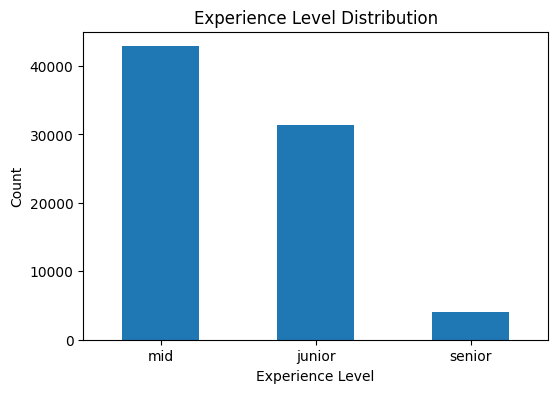

In [46]:
plt.figure(figsize=(6, 4))
df["experience_level_3class"].value_counts().plot(kind="bar")
plt.title("Experience Level Distribution")
plt.xlabel("Experience Level")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [47]:
df.groupby("experience_level_3class")["desc_word_count"].describe()

,count,mean,std,min,25%,50%,75%,max
experience_level_3class,,,,,,,,
junior,31368.0,531.835916,234.532063,92.0,354.0,505.0,684.0,1250.0
mid,42878.0,520.526890,262.799845,89.0,305.0,485.0,701.0,1244.0
senior,4117.0,601.601895,280.376257,91.0,370.0,587.0,815.0,1221.0


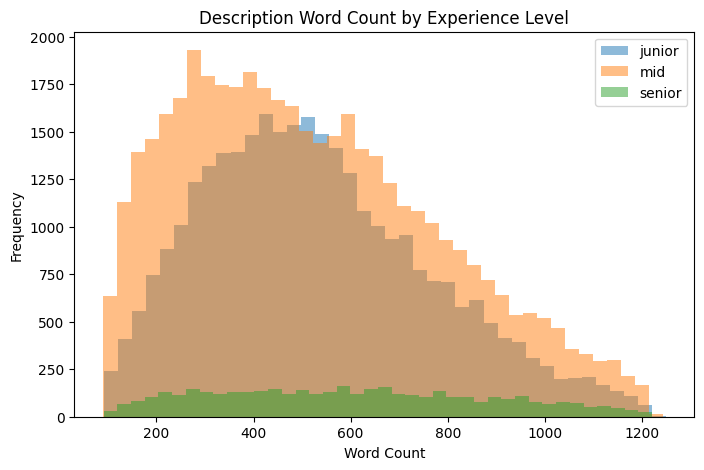

In [48]:
plt.figure(figsize=(8, 5))

for level in ["junior", "mid", "senior"]:
    subset = df[df["experience_level_3class"] == level]["desc_word_count"]
    plt.hist(subset, bins=40, alpha=0.5, label=level)

plt.title("Description Word Count by Experience Level")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [49]:
if "formatted_work_type" in df.columns:
    worktype_ct = pd.crosstab(df["formatted_work_type"], df["experience_level_3class"])
    display(worktype_ct)

experience_level_3class,junior,mid,senior
formatted_work_type,,,
Contract,1443,5660,153
Full-time,24925,34351,3865
Internship,502,42,2
Other,165,108,12
Part-time,4003,1910,60
Temporary,327,409,22
Volunteer,3,398,3


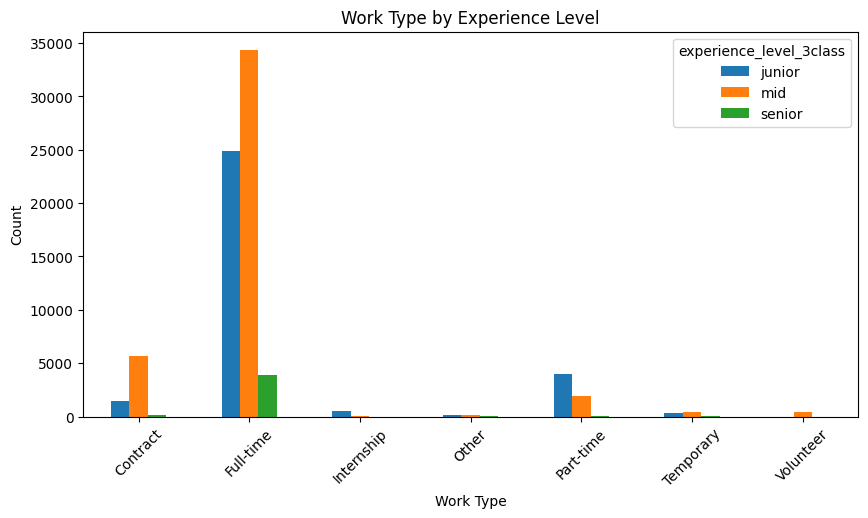

In [50]:
if "formatted_work_type" in df.columns:
    worktype_ct.plot(kind="bar", figsize=(10, 5))
    plt.title("Work Type by Experience Level")
    plt.xlabel("Work Type")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

In [51]:
if "remote_allowed" in df.columns:
    remote_ct = pd.crosstab(df["remote_allowed"].fillna("missing"), df["experience_level_3class"])
    display(remote_ct)

experience_level_3class,junior,mid,senior
remote_allowed,,,
1.0,1618,5897,776
missing,29750,36981,3341


In [52]:
STOPWORDS = {
    "and", "or", "the", "a", "an", "of", "to", "for", "in", "on", "with", "at",
    "by", "from", "level", "senior", "junior", "mid", "entry"
}

def get_top_words(series, n=20):
    words = []
    for text in series.dropna():
        for w in str(text).split():
            if w not in STOPWORDS and len(w) > 2:
                words.append(w)
    counter = Counter(words)
    return pd.DataFrame(counter.most_common(n), columns=["word", "count"])

for level in ["junior", "mid", "senior"]:
    print(f"\nTop title words for {level}:")
    display(get_top_words(df[df["experience_level_3class"] == level]["title_clean"], 15))


Top title words for junior:


,word,count
0,technician,2992
1,assistant,2398
2,associate,2336
3,specialist,2288
4,sales,2195
5,engineer,2080
6,service,1234
7,coordinator,1233
8,time,1178
9,representative,1073



Top title words for mid:


,word,count
0,manager,9894
1,engineer,4517
2,analyst,2520
3,nurse,2265
4,specialist,2030
5,sales,1818
6,lead,1701
7,project,1677
8,assistant,1600
9,associate,1464



Top title words for senior:


,word,count
0,director,2193
1,manager,371
2,president,298
3,vice,295
4,sales,255
5,operations,236
6,chief,210
7,development,194
8,management,189
9,business,176


In [53]:
if "skills_desc" in df.columns:
    print("Non-null skills_desc rows:", df["skills_desc"].notna().sum())
    print("Percent available:", round(df["skills_desc"].notna().mean() * 100, 2), "%")

Non-null skills_desc rows: 1898
Percent available: 2.42 %


In [54]:
df["desc_char_count"] = df["description_clean"].apply(len)
df["sentence_count"] = df["description"].astype(str).apply(
    lambda x: len(re.findall(r"[.!?]+", x)) if x else 0
)

df[["desc_word_count", "desc_char_count", "sentence_count"]].describe()

,desc_word_count,desc_char_count,sentence_count
count,78363.000000,78363.000000,78363.00000
mean,529.313273,3700.798897,26.71276
std,253.486540,1749.271523,15.53744
min,89.000000,549.000000,0.00000
25%,328.000000,2317.000000,15.00000
50%,498.000000,3486.000000,24.00000
75%,699.000000,4869.000000,36.00000
max,1250.000000,9502.000000,131.00000


In [55]:
def extract_years_experience(text):
    text = str(text).lower()

    patterns = [
        r'(\d+)\s*-\s*(\d+)\s+years?\s+of\s+experience',
        r'(\d+)\+?\s+years?\s+of\s+experience',
        r'at\s+least\s+(\d+)\s+years?\s+of\s+experience',
        r'minimum\s+of\s+(\d+)\s+years?\s+of\s+experience',
        r'(\d+)\s+years?\s+experience',
        r'(\d+)\+?\s+years?\s+experience',
        r'(\d+)\s*-\s*(\d+)\s+years?\s+experience',
        r'at\s+least\s+(\d+)\s+years?',
        r'minimum\s+(\d+)\s+years?'
    ]

    numbers = []

    for pattern in patterns:
        matches = re.findall(pattern, text)
        for match in matches:
            if isinstance(match, tuple):
                for m in match:
                    if str(m).isdigit():
                        numbers.append(int(m))
            else:
                if str(match).isdigit():
                    numbers.append(int(match))

    numbers = [n for n in numbers if 0 <= n <= 20]

    if numbers:
        return min(numbers), max(numbers)
    return np.nan, np.nan

In [56]:
years_extracted = df["description_clean"].apply(extract_years_experience)
df["min_years_extracted"] = years_extracted.apply(lambda x: x[0])
df["max_years_extracted"] = years_extracted.apply(lambda x: x[1])
df["has_years_mention"] = df["min_years_extracted"].notna().astype(int)

df[["min_years_extracted", "max_years_extracted", "has_years_mention"]].head()

,min_years_extracted,max_years_extracted,has_years_mention
70,NaN,NaN,0
84,NaN,NaN,0
85,10.0,10.0,1
101,NaN,NaN,0
102,NaN,NaN,0


In [57]:
def years_bucket(x):
    if pd.isna(x):
        return "not_mentioned"
    elif x <= 1:
        return "0-1"
    elif x <= 3:
        return "2-3"
    elif x <= 5:
        return "4-5"
    else:
        return "6+"

df["years_bucket"] = df["min_years_extracted"].apply(years_bucket)
df["years_bucket"].value_counts()

,count
years_bucket,
not_mentioned,56429
2-3,7792
4-5,5334
6+,4986
0-1,3822


In [58]:
junior_terms = [
    "entry level", "internship", "intern", "junior", "trainee", "graduate",
    "assist", "support", "willingness to learn", "learn", "under supervision"
]

mid_terms = [
    "collaborate", "implement", "maintain", "optimize", "hands on",
    "experience with", "independently", "contribute", "coordinate"
]

senior_terms = [
    "lead", "mentor", "architect", "strategy", "stakeholder", "oversee",
    "ownership", "own", "drive", "manage team", "leadership", "decision making"
]

In [59]:
def count_terms(text, terms):
    text = str(text).lower()
    count = 0
    for term in terms:
        count += len(re.findall(rf"\b{re.escape(term)}\b", text))
    return count

In [60]:
df["junior_term_count"] = df["description_clean"].apply(lambda x: count_terms(x, junior_terms))
df["mid_term_count"] = df["description_clean"].apply(lambda x: count_terms(x, mid_terms))
df["senior_term_count"] = df["description_clean"].apply(lambda x: count_terms(x, senior_terms))

df[["junior_term_count", "mid_term_count", "senior_term_count"]].describe()

,junior_term_count,mid_term_count,senior_term_count
count,78363.000000,78363.000000,78363.000000
mean,2.027794,1.776936,1.686714
std,2.253270,2.012191,2.448080
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,1.000000,1.000000,1.000000
75%,3.000000,3.000000,2.000000
max,35.000000,23.000000,34.000000


In [61]:
leadership_terms = ["lead", "mentor", "manage team", "supervise", "leadership"]
ownership_terms = ["ownership", "own", "responsible for", "take ownership"]
strategy_terms = ["strategy", "strategic", "roadmap", "vision"]
support_terms = ["assist", "support", "help", "coordinate"]

df["has_leadership_terms"] = df["description_clean"].apply(lambda x: int(count_terms(x, leadership_terms) > 0))
df["has_ownership_terms"] = df["description_clean"].apply(lambda x: int(count_terms(x, ownership_terms) > 0))
df["has_strategy_terms"] = df["description_clean"].apply(lambda x: int(count_terms(x, strategy_terms) > 0))
df["has_support_terms"] = df["description_clean"].apply(lambda x: int(count_terms(x, support_terms) > 0))

In [62]:
df["requires_bachelor"] = df["description_clean"].apply(
    lambda x: int(bool(re.search(r"\bbachelor\b|\bbs\b|\bba\b|\bundergraduate\b", x)))
)

df["requires_master"] = df["description_clean"].apply(
    lambda x: int(bool(re.search(r"\bmaster\b|\bms\b|\bm.sc\b", x)))
)

df["requires_phd"] = df["description_clean"].apply(
    lambda x: int(bool(re.search(r"\bphd\b|\bdoctorate\b", x)))
)

df["requires_certification"] = df["description_clean"].apply(
    lambda x: int(bool(re.search(r"\bcertification\b|\bcertified\b|\blicense\b|\blicensed\b", x)))
)

In [63]:
df["mentions_fast_paced"] = df["description_clean"].apply(lambda x: int("fast paced" in x))
df["mentions_deadlines"] = df["description_clean"].apply(lambda x: int("deadline" in x or "deadlines" in x))
df["mentions_independent_work"] = df["description_clean"].apply(
    lambda x: int("independently" in x or "self starter" in x or "self-starter" in x)
)
df["mentions_client_management"] = df["description_clean"].apply(
    lambda x: int("client" in x or "customer" in x)
)

In [64]:
df["entry_barrier_score"] = (
    df["has_leadership_terms"] * 2 +
    df["has_ownership_terms"] * 2 +
    df["has_strategy_terms"] * 2 +
    df["requires_master"] +
    df["requires_phd"] +
    df["mentions_independent_work"]
)

In [65]:
feature_cols = [
    "desc_word_count",
    "min_years_extracted",
    "max_years_extracted",
    "junior_term_count",
    "mid_term_count",
    "senior_term_count",
    "has_leadership_terms",
    "has_ownership_terms",
    "has_strategy_terms",
    "has_support_terms",
    "requires_bachelor",
    "requires_master",
    "requires_phd",
    "requires_certification",
    "mentions_fast_paced",
    "mentions_deadlines",
    "mentions_independent_work",
    "mentions_client_management",
    "entry_barrier_score"
]

df.groupby("experience_level_3class")[feature_cols].mean().round(2)

,desc_word_count,min_years_extracted,max_years_extracted,junior_term_count,mid_term_count,senior_term_count,has_leadership_terms,has_ownership_terms,has_strategy_terms,has_support_terms,requires_bachelor,requires_master,requires_phd,requires_certification,mentions_fast_paced,mentions_deadlines,mentions_independent_work,mentions_client_management,entry_barrier_score
experience_level_3class,,,,,,,,,,,,,,,,,,,
junior,531.84,4.97,5.74,2.08,1.42,0.94,0.27,0.41,0.46,0.72,0.20,0.11,0.01,0.40,0.03,0.08,0.16,0.68,2.54
mid,520.53,4.56,5.48,2.01,1.98,1.93,0.46,0.45,0.48,0.74,0.38,0.16,0.02,0.32,0.03,0.11,0.18,0.67,3.13
senior,601.60,6.59,7.71,1.83,2.35,4.85,0.80,0.55,0.74,0.76,0.49,0.23,0.03,0.27,0.02,0.11,0.12,0.67,4.55


In [66]:
pd.crosstab(df["years_bucket"], df["experience_level_3class"])

experience_level_3class,junior,mid,senior
years_bucket,,,
0-1,1951,1821,50
2-3,2318,5146,328
4-5,928,3959,447
6+,1366,2912,708
not_mentioned,24805,29040,2584


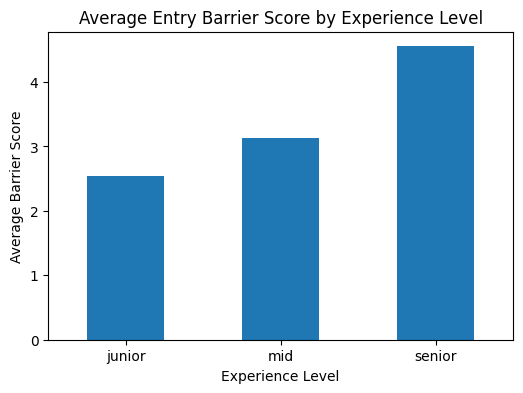

In [67]:
avg_barrier = df.groupby("experience_level_3class")["entry_barrier_score"].mean()

plt.figure(figsize=(6, 4))
avg_barrier.plot(kind="bar")
plt.title("Average Entry Barrier Score by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Average Barrier Score")
plt.xticks(rotation=0)
plt.show()

In [68]:
df["semantic_text"] = df["title_clean"] + " [SEP] " + df["description_clean"]
df[["title_clean", "semantic_text"]].head(3)

,title_clean,semantic_text
70,entry level oracle financial technology consultant,entry level oracle financial technology consultant [SEP] about revaturerevature is one of the largest and fastest-growing employers of emerging technology talent across the u.s. as a revature orac...
84,quality assurance manager,quality assurance manager [SEP] galerie is seeking an experienced quality assurance manager position overviewthe quality assurance manager will direct cross-functional teams qa product development...
85,validation engineer labware lims,validation engineer labware lims [SEP] validation engineer labware limsfoster city valength year to start likely extensions responsibilitiesvalidation plans and change controls for labware lims la...


In [69]:
print("Final shape:", df.shape)
df.head(3)

Final shape: (78363, 49)


,job_id,company_name,title,description,formatted_experience_level,formatted_work_type,skills_desc,min_salary,max_salary,med_salary,normalized_salary,pay_period,currency,location,remote_allowed,listed_time,original_listed_time,posting_domain,sponsored,work_type,desc_word_count_raw,experience_level_3class,title_clean,description_clean,desc_word_count,title_word_count,desc_char_count,sentence_count,min_years_extracted,max_years_extracted,has_years_mention,years_bucket,junior_term_count,mid_term_count,senior_term_count,has_leadership_terms,has_ownership_terms,has_strategy_terms,has_support_terms,requires_bachelor,requires_master,requires_phd,requires_certification,mentions_fast_paced,mentions_deadlines,mentions_independent_work,mentions_client_management,entry_barrier_score,semantic_text
70,2147609789,Revature,Entry Level Oracle Financial Technology Consultant,About RevatureRevature is one of the largest and fastest-growing employers of emerging technology talent across the U.S. As a Revature Oracle Financial Technology Associate you will have the oppor...,Entry level,Full-time,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"East Chicago, IN",NaN,1.712904e+12,1.712904e+12,NaN,0,FULL_TIME,191,junior,entry level oracle financial technology consultant,about revaturerevature is one of the largest and fastest-growing employers of emerging technology talent across the u.s. as a revature oracle financial technology associate you will have the oppor...,194,6,1330,9,NaN,NaN,0,not_mentioned,2,1,1,0,1,1,0,1,0,0,0,0,0,0,0,4,entry level oracle financial technology consultant [SEP] about revaturerevature is one of the largest and fastest-growing employers of emerging technology talent across the u.s. as a revature orac...
84,2457183642,Galerie Candy and Gifts,Quality Assurance Manager,"Galerie is seeking an experienced Quality Assurance Manager! \n\nPosition OverviewThe Quality Assurance Manager will direct cross-functional teams (QA, Product Development, Warehouse, etc.) throug...",Mid-Senior level,Full-time,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Hebron, KY",NaN,1.713533e+12,1.713533e+12,NaN,0,FULL_TIME,663,mid,quality assurance manager,galerie is seeking an experienced quality assurance manager position overviewthe quality assurance manager will direct cross-functional teams qa product development warehouse etc. through annual b...,668,3,5027,58,NaN,NaN,0,not_mentioned,1,6,4,1,1,0,1,0,1,0,0,0,0,0,1,5,quality assurance manager [SEP] galerie is seeking an experienced quality assurance manager position overviewthe quality assurance manager will direct cross-functional teams qa product development...
85,2558399667,"I.T. Solutions, Inc.","Validation Engineer, Labware LIMS","Validation Engineer, Labware LIMSFoster City, VALength: year to start, likely extensions\nResponsibilitiesValidation Plans and Change Controls for Labware LIMS (Laboratory Information Management S...",Mid-Senior level,Contract,NaN,60.0,70.0,NaN,135200.0,HOURLY,USD,"Foster City, CA",NaN,1.713480e+12,1.713480e+12,NaN,0,CONTRACT,254,mid,validation engineer labware lims,validation engineer labware limsfoster city valength year to start likely extensions responsibilitiesvalidation plans and change controls for labware lims laboratory information management system ...,259,4,2058,13,10.0,10.0,1,6+,1,1,2,0,0,1,1,1,1,0,0,0,0,0,0,3,validation engineer labware lims [SEP] validation engineer labware limsfoster city valength year to start likely extensions responsibilitiesvalidation plans and change controls for labware lims la...


In [70]:
final_missing = df.isna().sum().sort_values(ascending=False)
final_missing[final_missing > 0].head(20)

,0
skills_desc,76465
med_salary,74122
remote_allowed,70072
max_salary,57924
min_salary,57924
min_years_extracted,56429
max_years_extracted,56429
normalized_salary,53683
pay_period,53683
currency,53683


In [71]:
# full_output_file = "postings_cleaned_feature_engineered.csv"
# df.to_csv(full_output_file, index=False)
# print(f"Saved: {full_output_file}")

In [72]:
reduction_file = "reduction_log.csv"
reduction_df.to_csv(reduction_file, index=False)
print(f"Saved: {reduction_file}")

Saved: reduction_log.csv


In [73]:
cols_to_keep_for_n2 = [
    "job_id",
    "title_clean",
    "description_clean",
    "semantic_text",
    "experience_level_3class",
    "min_years_extracted",
    "max_years_extracted",
    "has_years_mention",
    "years_bucket",
    "junior_term_count",
    "mid_term_count",
    "senior_term_count",
    "has_leadership_terms",
    "has_ownership_terms",
    "has_strategy_terms",
    "has_support_terms",
    "requires_bachelor",
    "requires_master",
    "requires_phd",
    "requires_certification",
    "mentions_fast_paced",
    "mentions_deadlines",
    "mentions_independent_work",
    "mentions_client_management",
    "entry_barrier_score"
]

cols_to_keep_for_n2 = [c for c in cols_to_keep_for_n2 if c in df.columns]

df_n2 = df[cols_to_keep_for_n2].copy()

print("Notebook 2 dataset shape:", df_n2.shape)
df_n2.head()

Notebook 2 dataset shape: (78363, 25)


,job_id,title_clean,description_clean,semantic_text,experience_level_3class,min_years_extracted,max_years_extracted,has_years_mention,years_bucket,junior_term_count,mid_term_count,senior_term_count,has_leadership_terms,has_ownership_terms,has_strategy_terms,has_support_terms,requires_bachelor,requires_master,requires_phd,requires_certification,mentions_fast_paced,mentions_deadlines,mentions_independent_work,mentions_client_management,entry_barrier_score
70,2147609789,entry level oracle financial technology consultant,about revaturerevature is one of the largest and fastest-growing employers of emerging technology talent across the u.s. as a revature oracle financial technology associate you will have the oppor...,entry level oracle financial technology consultant [SEP] about revaturerevature is one of the largest and fastest-growing employers of emerging technology talent across the u.s. as a revature orac...,junior,NaN,NaN,0,not_mentioned,2,1,1,0,1,1,0,1,0,0,0,0,0,0,0,4
84,2457183642,quality assurance manager,galerie is seeking an experienced quality assurance manager position overviewthe quality assurance manager will direct cross-functional teams qa product development warehouse etc. through annual b...,quality assurance manager [SEP] galerie is seeking an experienced quality assurance manager position overviewthe quality assurance manager will direct cross-functional teams qa product development...,mid,NaN,NaN,0,not_mentioned,1,6,4,1,1,0,1,0,1,0,0,0,0,0,1,5
85,2558399667,validation engineer labware lims,validation engineer labware limsfoster city valength year to start likely extensions responsibilitiesvalidation plans and change controls for labware lims laboratory information management system ...,validation engineer labware lims [SEP] validation engineer labware limsfoster city valength year to start likely extensions responsibilitiesvalidation plans and change controls for labware lims la...,mid,10.0,10.0,1,6+,1,1,2,0,0,1,1,1,1,0,0,0,0,0,0,3
101,2989631782,administrative assistant - concur,global financial services firm is seeking an experienced executive administrative assistant to join their new york city offices. remarkable opportunity for qualified executive administrative assis...,administrative assistant - concur [SEP] global financial services firm is seeking an experienced executive administrative assistant to join their new york city offices. remarkable opportunity for ...,mid,NaN,NaN,0,not_mentioned,2,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0
102,3018278978,seasonal office administrator,seasonal office admin responsibilities will be checking in trucks as they bring cherry loads from various farmerswill document details about loadwill also create labels and tags for produce requir...,seasonal office administrator [SEP] seasonal office admin responsibilities will be checking in trucks as they bring cherry loads from various farmerswill document details about loadwill also creat...,junior,NaN,NaN,0,not_mentioned,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [74]:
n2_output_file = "postings_for_semantic_pipeline.csv"
df_n2.to_csv(n2_output_file, index=False)
print(f"Saved: {n2_output_file}")

Saved: postings_for_semantic_pipeline.csv


In [75]:
# ============================================================
# OUTPUT FILE SHA-256 CHECKSUM
# ============================================================
import hashlib
OUTPUT_FILE = "postings_for_semantic_pipeline.csv"
sha256_out = hashlib.sha256()
with open(OUTPUT_FILE, "rb") as f:
    for block in iter(lambda: f.read(8192), b""):
        sha256_out.update(block)
print(f"Output file: {OUTPUT_FILE}")
print(f"SHA-256:     {sha256_out.hexdigest()}")

Output file: postings_for_semantic_pipeline.csv
SHA-256:     78d20db6ffb031ca8f1480246786b49c0d9e4d7ff152c03a7a87f9669e78fb81


In [76]:
print("Final row count:", len(df))

print("\nClass distribution:")
print(df["experience_level_3class"].value_counts())

print("\nYears mention rate:")
print(round(df["has_years_mention"].mean() * 100, 2), "%")

print("\nAverage barrier score by class:")
print(df.groupby("experience_level_3class")["entry_barrier_score"].mean().round(2))

Final row count: 78363

Class distribution:
experience_level_3class
mid       42878
junior    31368
senior     4117
Name: count, dtype: int64

Years mention rate:
27.99 %

Average barrier score by class:
experience_level_3class
junior    2.54
mid       3.13
senior    4.55
Name: entry_barrier_score, dtype: float64


In [77]:
manifest = {
    "input_file": DATA_FILE,
    "input_sha256": dataset_hash_info["sha256"],
    "random_seed": RANDOM_SEED,
    "final_row_count": int(len(df)),
    "notebook2_row_count": int(len(df_n2)),
    "min_words_filter": MIN_WORDS,
    "max_words_filter": MAX_WORDS,
    "experience_mapping": {
        "junior": sorted(list(JUNIOR_LABELS)),
        "mid": sorted(list(MID_LABELS)),
        "senior": sorted(list(SENIOR_LABELS))
    },
    "notes": {
        "taxonomy_removed": True,
        "skill_extraction_stage": "Notebook 3 via LLM at community level"
    }
}

with open("reproducibility_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print(json.dumps(manifest, indent=2))
print("Saved: reproducibility_manifest.json")

{
  "input_file": "postings.csv",
  "input_sha256": "de33f27c8d1b226014e0cede003404e9b0acb66db718671fda9b3e3538eca6ea",
  "random_seed": 42,
  "final_row_count": 78363,
  "notebook2_row_count": 78363,
  "min_words_filter": 100,
  "max_words_filter": 1200,
  "experience_mapping": {
    "junior": [
      "apprentice",
      "entry level",
      "graduate",
      "internship",
      "jr",
      "junior",
      "trainee"
    ],
    "mid": [
      "associate",
      "experienced",
      "intermediate",
      "mid level",
      "mid senior level",
      "mid-level",
      "mid-senior level",
      "regular",
      "specialist"
    ],
    "senior": [
      "c suite",
      "c-level",
      "c-suite",
      "chief",
      "director",
      "executive",
      "head",
      "lead",
      "manager",
      "officer",
      "principal",
      "senior",
      "sr",
      "vice president",
      "vp"
    ]
  },
  "notes": {
    "taxonomy_removed": true,
    "skill_extraction_stage": "Notebook 3 via L